In [2]:
from cluster_functions import *

import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import pearsonr
from scipy.stats import ks_2samp


import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import os
#Caminho para dados dos aglomerados
path = './Aglomerados/'

import warnings
warnings.filterwarnings('ignore')

In [3]:
df =pd.read_csv('Dados/results.csv', index_col='Cluster')
benchmark_subsample = df[(df.Av<0.5) & (df.dist<1.5)].copy()

print(df[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members', 'bin_frac_corr','e_bin_frac', 'bin_frac_05_corr', 'e_bin_frac_05']].describe().round(2).T)



                  count    mean     std    min     25%     50%     75%  \
dist              771.0    1.75    1.00   0.14    0.94    1.64    2.37   
age               771.0    8.18    0.64   6.67    7.79    8.25    8.68   
FeH               771.0   -0.04    0.11  -0.37   -0.11   -0.04    0.03   
Av                771.0    1.41    0.79   0.01    0.81    1.38    1.92   
mass_total        771.0  544.47  447.32  61.00  245.00  413.00  678.00   
n_members         771.0  319.75  244.32  43.00  153.00  250.00  405.50   
bin_frac_corr     771.0    0.51    0.05   0.30    0.49    0.52    0.54   
e_bin_frac        771.0    0.05    0.02   0.02    0.04    0.05    0.07   
bin_frac_05_corr  771.0    0.32    0.05   0.18    0.28    0.32    0.36   
e_bin_frac_05     771.0    0.05    0.02   0.02    0.04    0.05    0.07   

                      max  
dist                 6.87  
age                  9.59  
FeH                  0.43  
Av                   4.49  
mass_total        3434.00  
n_members        

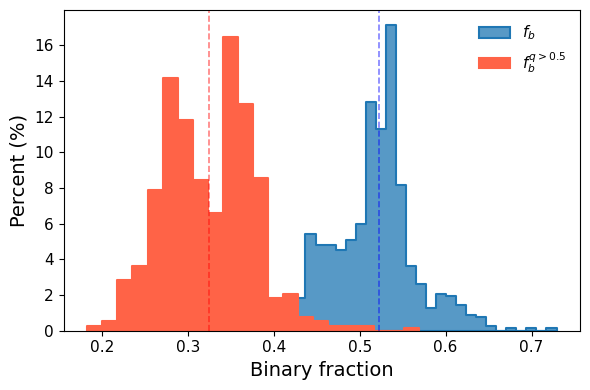

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

# Histogramas
sns.histplot(
    data=df, x="bin_frac_corr",
    element="step", stat="percent",
    linewidth=1.5, ax=ax, label=r"$f_b$"
)

sns.histplot(
    data=df, x="bin_frac_05_corr",
    element="step", stat="percent",
    linewidth=1.5, color="tomato",
    ax=ax, label=r"$f_b^{q>0.5}$",
    alpha=1
)

# Medianas
ax.axvline(df.bin_frac_corr.median(), ls="--", lw=1.2, color='b', alpha=0.5)
ax.axvline(df.bin_frac_05_corr.median(), ls="--", lw=1.2, color="r", alpha=0.5)

# Labels
ax.set_xlabel("Binary fraction", fontdict=font)
ax.set_ylabel("Percent (%)", fontdict=font)

# Ticks
ax.tick_params(labelsize=11,)

# Legenda
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("Figures/dist_fb.png", dpi=300, bbox_inches="tight")
plt.show()


In [5]:
df[df['bin_frac']>0.8][['dist', 'Av','age','FeH',]]

,dist,Av,age,FeH
Cluster,,,,
Berkeley_1,3.541,2.050,8.179,-0.141
Berkeley_8,3.013,2.209,9.527,-0.175
Bica_2,1.588,4.486,6.673,0.059
FSR_0977,1.781,1.595,8.930,-0.147
Haffner_16,2.786,0.388,8.324,-0.058
IC_361,3.385,2.374,9.014,-0.229
Kronberger_4,6.866,2.575,8.908,0.072
LP_866,2.104,2.261,9.521,0.099
NGC_2509,2.831,0.055,9.146,0.426


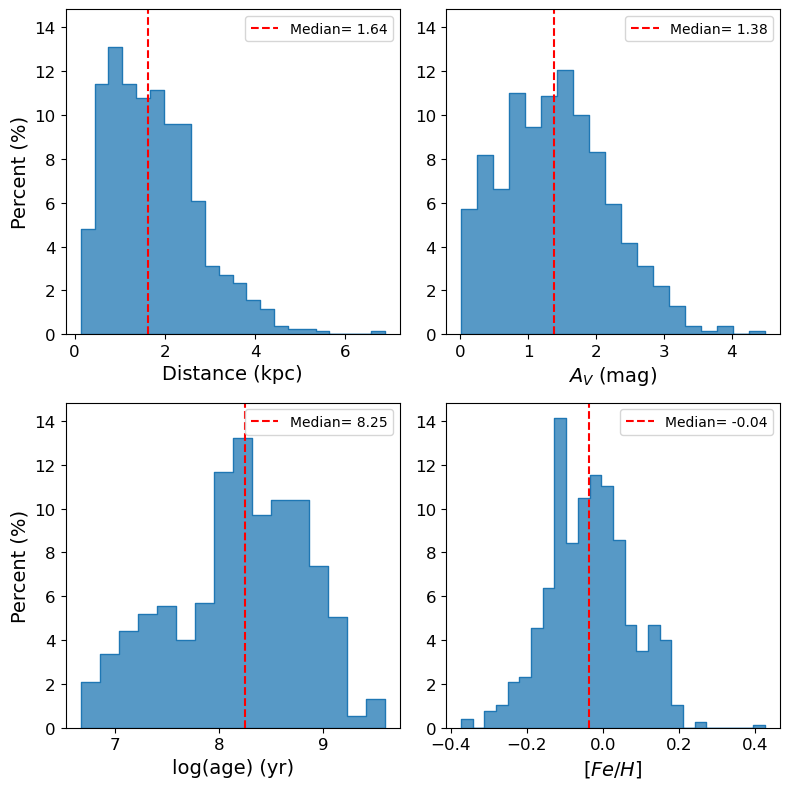

In [8]:
fig, axs = plt.subplots(2,2, figsize = (8,8), sharey=True)

sns.histplot(data=df, x='dist', ax = axs[0,0], stat='percent', element='step',)
axs[0,0].set_xlabel('Distance (kpc)', fontdict=font)
axs[0,0].axvline(x=df['dist'].median(), color='r',ls='--',  label = f'Median= {df.dist.median():.2f}')
axs[0,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 0].legend()


sns.histplot(data=df, x='Av', ax = axs[0,1], stat='percent', element='step')
axs[0,1].set_xlabel(r'$A_V$ (mag)', fontdict=font)
axs[0,1].axvline(x=df['Av'].median(), color='r',ls='--', label = f'Median= {df.Av.median():.2f}')
axs[0,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 1].legend()

sns.histplot(data=df, x='age', ax = axs[1,0], stat='percent', element='step')
axs[1,0].set_xlabel('log(age) (yr)', fontdict=font)
axs[1,0].axvline(x=df['age'].median(), color='r',ls='--', label = f'Median= {df.age.median():.2f}')
axs[1,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1, 0].legend()

sns.histplot(data=df, x='FeH', ax = axs[1,1], stat='percent', element='step')
axs[1,1].set_xlabel(r'[$Fe/H$]', fontdict=font)
axs[1,1].axvline(x=df['FeH'].median(), color='r',ls='--', label = f'Median= {df.FeH.median():.2f}')
axs[1,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1,1].legend()

axs[0,0].set_ylabel('Percent (%)', fontdict=font)
axs[1,0].set_ylabel('Percent (%)', fontdict=font)



plt.tight_layout()
plt.savefig('Figures/clusters_properties.png',bbox_inches='tight', dpi=300)
plt.show()

In [126]:
print(df[['bin_frac','e_bin_frac','bin_frac_0.5','e_bin_frac_0.5']].describe().round(2).T)

                count  mean   std   min   25%   50%   75%   max
bin_frac        771.0  0.58  0.11  0.23  0.51  0.58  0.66  0.90
e_bin_frac      771.0  0.15  0.07  0.03  0.09  0.13  0.18  0.46
bin_frac_0.5    771.0  0.40  0.11  0.13  0.32  0.40  0.47  0.75
e_bin_frac_0.5  771.0  0.15  0.08  0.02  0.09  0.13  0.19  0.42


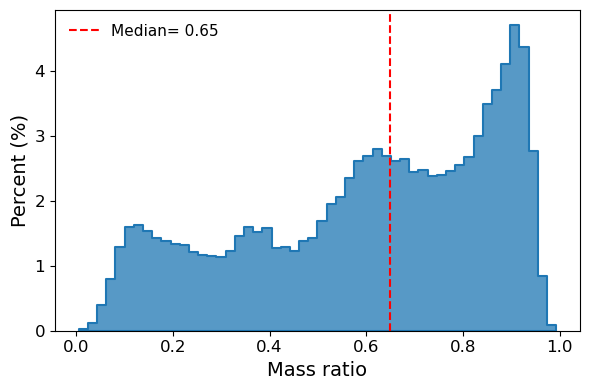

In [42]:
data = pd.read_csv('Dados/data.csv', index_col='Cluster')

fig= plt.figure(figsize= (6,4))
sns.histplot(x=data[data.q>0]['q'], stat='percent', element='step', lw=1.5)
median = data[data.q>0]['q'].median()
plt.axvline(median, ls='--', c='r', label = f'Median= {median:.2f}')

plt.xlabel('Mass ratio', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
plt.tick_params(labelsize=labelsize)
plt.legend(frameon=False, fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig('Figures/dist_mass_ratio.png',  dpi=300, bbox_inches="tight")
plt.show()

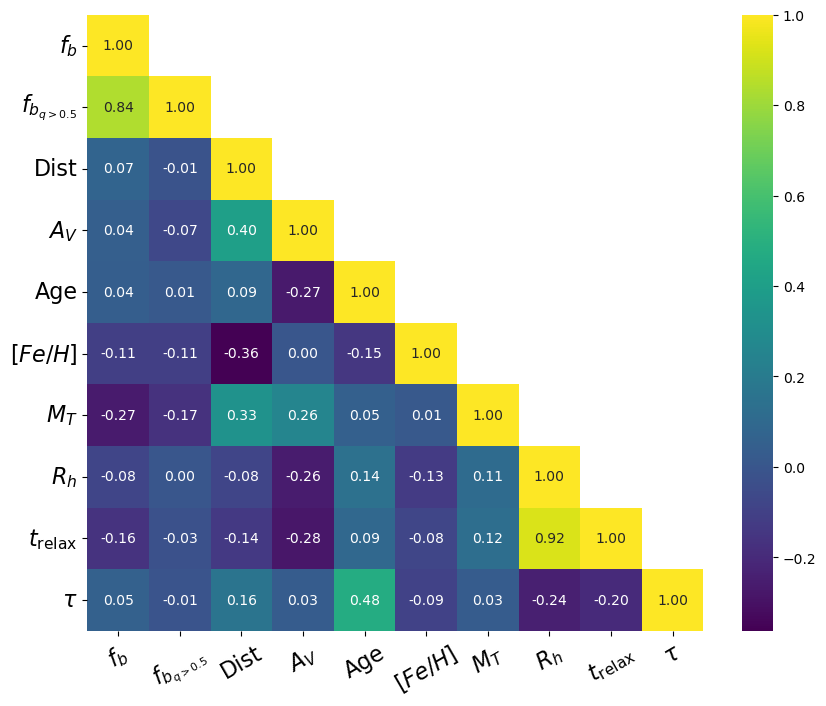

In [32]:
nome_vars = {
    'bin_frac_corr': r'$f_b$',
    'bin_frac_05_corr': r'$f_{b_{q>0.5}}$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$',
}

cols = list(nome_vars.keys())
corr = df[cols].corr(method='pearson')
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(10, 8))
cmap = palette 

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(30) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 

plt.savefig('Figures/corr.png',bbox_inches='tight')
plt.show()